In [38]:
import pandas as pd
import numpy as np

In [39]:
df = pd.read_csv('HRdataset.csv')
df.head()

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,Elijiah Gray,16.0,Indeed,Fully Meets,4.84,5,0,1/3/2019,0,15
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Webster Butler,39.0,Google Search,Fully Meets,5.00,4,0,2/1/2016,0,2


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 311 entries, 0 to 310
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Employee_Name               311 non-null    object 
 1   EmpID                       311 non-null    int64  
 2   MarriedID                   311 non-null    int64  
 3   MaritalStatusID             311 non-null    int64  
 4   GenderID                    311 non-null    int64  
 5   EmpStatusID                 311 non-null    int64  
 6   DeptID                      311 non-null    int64  
 7   PerfScoreID                 311 non-null    int64  
 8   FromDiversityJobFairID      311 non-null    int64  
 9   Salary                      311 non-null    int64  
 10  Termd                       311 non-null    int64  
 11  PositionID                  311 non-null    int64  
 12  Position                    311 non-null    object 
 13  State                       311 non

In [24]:
df.isna().sum()

Employee_Name                   0
EmpID                           0
MarriedID                       0
MaritalStatusID                 0
GenderID                        0
EmpStatusID                     0
DeptID                          0
PerfScoreID                     0
FromDiversityJobFairID          0
Salary                          0
Termd                           0
PositionID                      0
Position                        0
State                           0
Zip                             0
DOB                             0
Sex                             0
MaritalDesc                     0
CitizenDesc                     0
HispanicLatino                  0
RaceDesc                        0
DateofHire                      0
DateofTermination             207
TermReason                      0
EmploymentStatus                0
Department                      0
ManagerName                     0
ManagerID                       8
RecruitmentSource               0
PerformanceSco

In [25]:
# drop null values or fill null values

df = df.fillna("0")
df = df.dropna()

In [26]:
df.isna().sum()

Employee_Name                 0
EmpID                         0
MarriedID                     0
MaritalStatusID               0
GenderID                      0
EmpStatusID                   0
DeptID                        0
PerfScoreID                   0
FromDiversityJobFairID        0
Salary                        0
Termd                         0
PositionID                    0
Position                      0
State                         0
Zip                           0
DOB                           0
Sex                           0
MaritalDesc                   0
CitizenDesc                   0
HispanicLatino                0
RaceDesc                      0
DateofHire                    0
DateofTermination             0
TermReason                    0
EmploymentStatus              0
Department                    0
ManagerName                   0
ManagerID                     0
RecruitmentSource             0
PerformanceScore              0
EngagementSurvey              0
EmpSatis

In [27]:
df.duplicated().sum()

0

In [28]:
attrition_rate = (df['EmploymentStatus'].value_counts(normalize=True)) * 100
attrition_rate

EmploymentStatus
Active                    66.559486
Voluntarily Terminated    28.295820
Terminated for Cause       5.144695
Name: proportion, dtype: float64

## ***Which department has the highest number of employees?***

In [29]:
df['Department'].value_counts()

Department
Production              209
IT/IS                    50
Sales                    31
Software Engineering     11
Admin Offices             9
Executive Office          1
Name: count, dtype: int64

### **Interpretation**

* Displays count of employees in each department
* The department with the highest value = largest workforce

### **Insight**
* Production has the highest employee count which means it has highest resource allocation

## ***What is the average salary distribution across employees?***

In [30]:
df['Salary'].describe()

count       311.000000
mean      69020.684887
std       25156.636930
min       45046.000000
25%       55501.500000
50%       62810.000000
75%       72036.000000
max      250000.000000
Name: Salary, dtype: float64

Salary skewness :  3.30618080924006


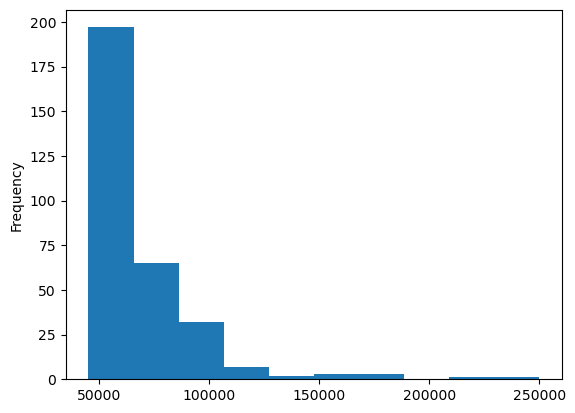

In [31]:
df['Salary'].plot(kind='hist')
print("Salary skewness : " ,df['Salary'].skew())

### **Interpretation**

* Skewness = +3.306 → Highly Positively Skewed Distribution
* Presence of extreme high-value outliers (e.g., executives/top roles)
* Mean will be greater than median due to high salary values

### **Insight**
* Few employees earn very high salaries
* Majority earn lower to mid-range salaries
* It helps HR to undertand the Pay Structure

## ***Does salary impact attrition?***

In [32]:
df.groupby('EmploymentStatus')['Salary'].mean()

EmploymentStatus
Active                    70694.033816
Terminated for Cause      75264.875000
Voluntarily Terminated    63949.204545
Name: Salary, dtype: float64

### **Interpretation**
* Employees who left voluntarily have lowest average salary (~63K)
* Active employees earn moderate salary (~70K)
* Employees terminated for cause have highest salary (~75K)

### **Insights**
* Lower salary may be a reason for voluntary attrition
* Employees leaving by choice might be:
  * Underpaid
  * Looking for better opportunities

## ***Which department has the highest attrition rate?***

In [41]:
pd.crosstab(df['Department'], df['EmploymentStatus'], normalize='index') * 100

EmploymentStatus,Active,Terminated for Cause,Voluntarily Terminated
Department,,,
Admin Offices,77.777778,11.111111,11.111111
Executive Office,100.000000,0.000000,0.000000
IT/IS,80.000000,8.000000,12.000000
Production,60.287081,3.827751,35.885167
Sales,83.870968,6.451613,9.677419
Software Engineering,63.636364,9.090909,27.272727


**What this code does?**

* Creates a percentage distribution
Shows:
* Out of 100 employees in each department, how many are:
  1.  Active
  2. Terminated
  3. Voluntarily Left

### **Interpretation**

* Each row shows % distribution of employee status within a department
* Helps identify which departments have higher attrition
* Voluntary termination indicates employees leaving by choice

### **Insights**

* Production has highest attrition (~36%) → major concern
* Software Engineering also shows high exits (~27%) → competitive job market
* Executive & Sales are stable → strong retention
* Voluntary attrition is higher than termination → dissatisfaction-driven exits

## ***Is there a relationship between age and salary?***

In [34]:
# Since we do not have any Age column we need to create a new column

df['DOB'] = pd.to_datetime(df['DOB'])
df['Age'] = (pd.to_datetime('today') - df['DOB']).dt.days // 365

C:\Users\mahip\AppData\Local\Temp\ipykernel_13640\2508238823.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['DOB'] = pd.to_datetime(df['DOB'])


,Age,Salary
Age,1.000000,-0.044253
Salary,-0.044253,1.000000


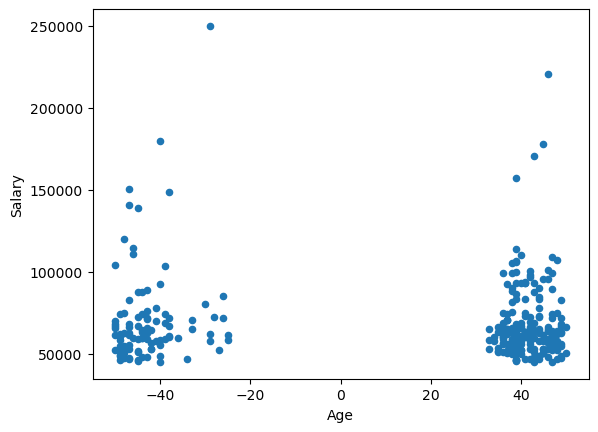

In [35]:
df.plot(x='Age', y='Salary', kind='scatter')
df[['Age', 'Salary']].corr()

### **Interpretation**

* Scatter plot shows no clear upward or downward trend between Age and Salary
* Correlation value is -0.044 → almost zero (very weak relationship)
* Salary is spread across all age groups, not dependent on age
* Presence of outliers (very high salaries) in different age ranges

### **Key Insights**
* Age does not significantly impact salary in this dataset
* Salary is likely driven by other factors (role, experience, department)
* Both younger and older employees can earn similar salary ranges
* A few high earners exist → may represent senior roles or leadership positions

## ***Does work-life balance affect attrition?***

In [36]:
pd.crosstab(df['EmpSatisfaction'], df['EmploymentStatus'], normalize='index') * 100

EmploymentStatus,Active,Terminated for Cause,Voluntarily Terminated
EmpSatisfaction,,,
1,100.000000,0.000000,0.000000
2,55.555556,11.111111,33.333333
3,69.444444,4.629630,25.925926
4,59.574468,6.382979,34.042553
5,70.408163,4.081633,25.510204


### **Interpretation**

* Table shows % distribution of employment status across satisfaction levels (1–5)
* Lower satisfaction levels (2 & 4) show higher voluntary attrition (~33–34%)
* Higher satisfaction (3 & 5) shows better retention (~69–70% active)
* Satisfaction level 1 shows 100% active (likely very few records or anomaly)

### **Key Insights**
* Satisfaction level 2 & 4 have highest voluntary exits (~33–34%)
* Even high satisfaction (5) has ~25% attrition → not fully protective
* Satisfaction impacts attrition, but not the only factor

## ***Which job roles are highest paid?***

In [37]:
#Code (Highest Paid Roles)
df.groupby('Department')['Salary'].mean().sort_values(ascending=False)

Department
Executive Office        250000.000000
IT/IS                    97064.640000
Software Engineering     94989.454545
Admin Offices            71791.888889
Sales                    69061.258065
Production               59953.545455
Name: Salary, dtype: float64

### **Insights**
* Leadership roles (Executive Office) are highest paid
* Technical roles (IT/Software) offer higher salaries than non-tech roles
* Production roles are lowest paid → possible dissatisfaction risk
* Salary distribution reflects skill level & job complexity

------

# **Thank You for Attending the Session**

## ***“EDA is not just about finding patterns—it’s about questioning them.”***